<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/wayboe-HW3/2026/HW/Wayboe/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shane Marshall HW3

I spun around in my chair at home and took data using Phyphox. Some challewnges I found was slowing down very quickly, so I spun my self for longer to get better results.

In [19]:
import numpy as np
import pandas as pa
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [20]:
df = pa.read_csv('wayboe_HW3_data.csv', delimiter=';')

display(df.head(10))

,Time (s),Gyroscope x (rad/s),Gyroscope y (rad/s),Gyroscope z (rad/s),Absolute (rad/s)
0,0.001094,0.507546,-3.066404,-1.756506,3.570119
1,0.011081,0.215692,-3.091910,-1.759398,3.563974
2,0.021068,-0.182535,-3.281151,-1.770718,3.732923
3,0.031055,-0.554848,-3.543425,-1.812970,4.018778
4,0.041042,-0.804115,-3.746672,-1.849804,4.255106
5,0.051029,-0.893138,-3.868406,-1.862217,4.385215
6,0.061016,-0.816734,-3.853495,-1.879790,4.364641
7,0.071004,-0.598219,-3.742173,-1.922252,4.249327
8,0.080991,-0.299512,-3.551040,-1.971285,4.072537
9,0.090978,0.018274,-3.267061,-2.024712,3.843629


In [21]:
display(df.describe())

,Time (s),Gyroscope x (rad/s),Gyroscope y (rad/s),Gyroscope z (rad/s),Absolute (rad/s)
count,3148.000000,3148.000000,3148.000000,3148.000000,3148.000000
mean,15.715560,-0.016019,-1.807238,-0.914824,2.090246
std,9.076990,0.120199,1.418896,0.727452,1.513591
min,0.001094,-0.893138,-4.086718,-2.185360,0.004243
25%,7.858422,-0.090883,-3.078929,-1.582599,0.341595
50%,15.715635,-0.022858,-2.478710,-1.130860,2.738227
75%,23.572734,0.028914,-0.125265,-0.073629,3.471880
max,31.429739,0.644209,0.817334,0.338842,4.635256


In [22]:
df.isnull().sum()

,0
Time (s),0
Gyroscope x (rad/s),0
Gyroscope y (rad/s),0
Gyroscope z (rad/s),0
Absolute (rad/s),0


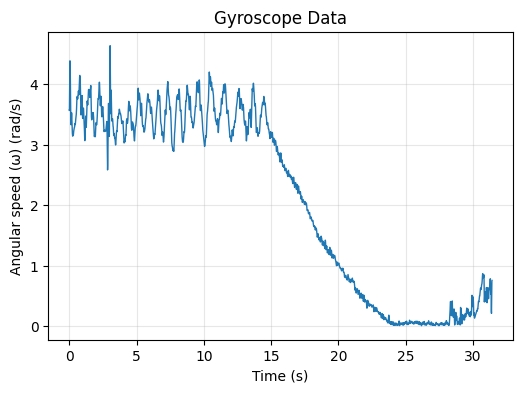

In [25]:
import matplotlib.pyplot as plt

time = df['Time (s)']
omega = df['Absolute (rad/s)']

plt.figure(figsize=(6,4))
plt.plot(time, omega, lw=1)
plt.xlabel('Time (s)')
plt.ylabel('Angular speed (ω) (rad/s)')
plt.title('Gyroscope Data')
plt.grid(True, alpha=0.3)
plt.show()


Trimmed interval: 14.0 s to 27.5 s
Number of fitted points: 1352

Summary of trimmed angular speed data:
mean    1.148723
std     1.134595
min     0.004243
max     3.795965
Name: Absolute (rad/s), dtype: float64


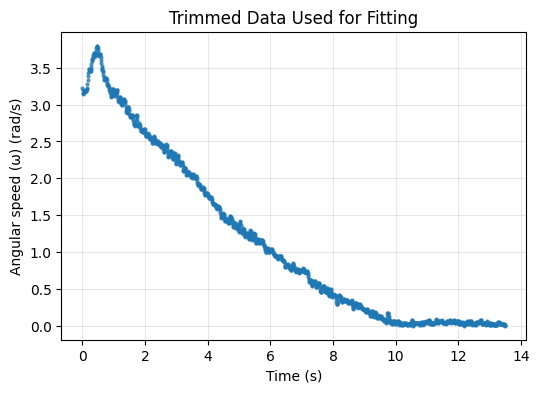

In [38]:
t_start = 14.0
t_end = 27.5

mask = (time >= t_start) & (time <= t_end)
time_fit = time[mask] - time[mask].iloc[0]   # reset time so fit starts at t = 0
omega_fit = omega[mask]

print(f'\nTrimmed interval: {t_start:.1f} s to {t_end:.1f} s')
print(f'Number of fitted points: {len(time_fit)}')
print('\nSummary of trimmed angular speed data:')
print(pa.Series(omega_fit).describe()[['mean', 'std', 'min', 'max']])

plt.figure(figsize=(6,4))
plt.plot(time_fit, omega_fit, linestyle='None', marker=".", markersize=4, alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Angular speed (ω) (rad/s)')
plt.title('Trimmed Data Used for Fitting')
plt.grid(True, alpha=0.3)
plt.show()

The data was aletered to show the time interval where the decay was most prominat

omega_0 = 4.105 ± 0.021 rad/s
beta    = 0.244 ± 0.002 s^-1


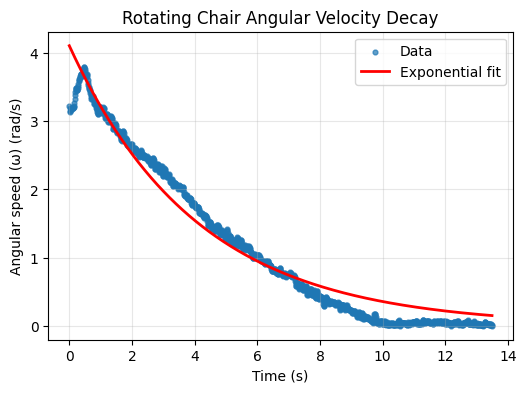

In [37]:
def exp_decay(t, omega0, beta):
    return omega0 * np.exp(-beta * t)

p0 = [omega_fit.iloc[0], 0.2]

popt, pcov = curve_fit(exp_decay, time_fit, omega_fit, p0=p0, maxfev=10000)
omega0_fit, beta_fit = popt
uncertainties = np.sqrt(np.diag(pcov))

omega_model = exp_decay(time_fit, *popt)
residuals = omega_fit - omega_model

print(f"omega_0 = {omega0_fit:.3f} ± {uncertainties[0]:.3f} rad/s")
print(f"beta    = {beta_fit:.3f} ± {uncertainties[1]:.3f} s^-1")

plt.figure(figsize=(6, 4))
plt.scatter(time_fit, omega_fit, s=12, alpha=0.7, label='Data')
plt.plot(time_fit, omega_model, 'r-', linewidth=2, label='Exponential fit')
plt.xlabel('Time (s)')
plt.ylabel('Angular speed (ω) (rad/s)')
plt.title('Rotating Chair Angular Velocity Decay')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The fit makes sense, the data for the most part follows the decay equation $\omega_0 * \text{exp}(-\beta * t)$

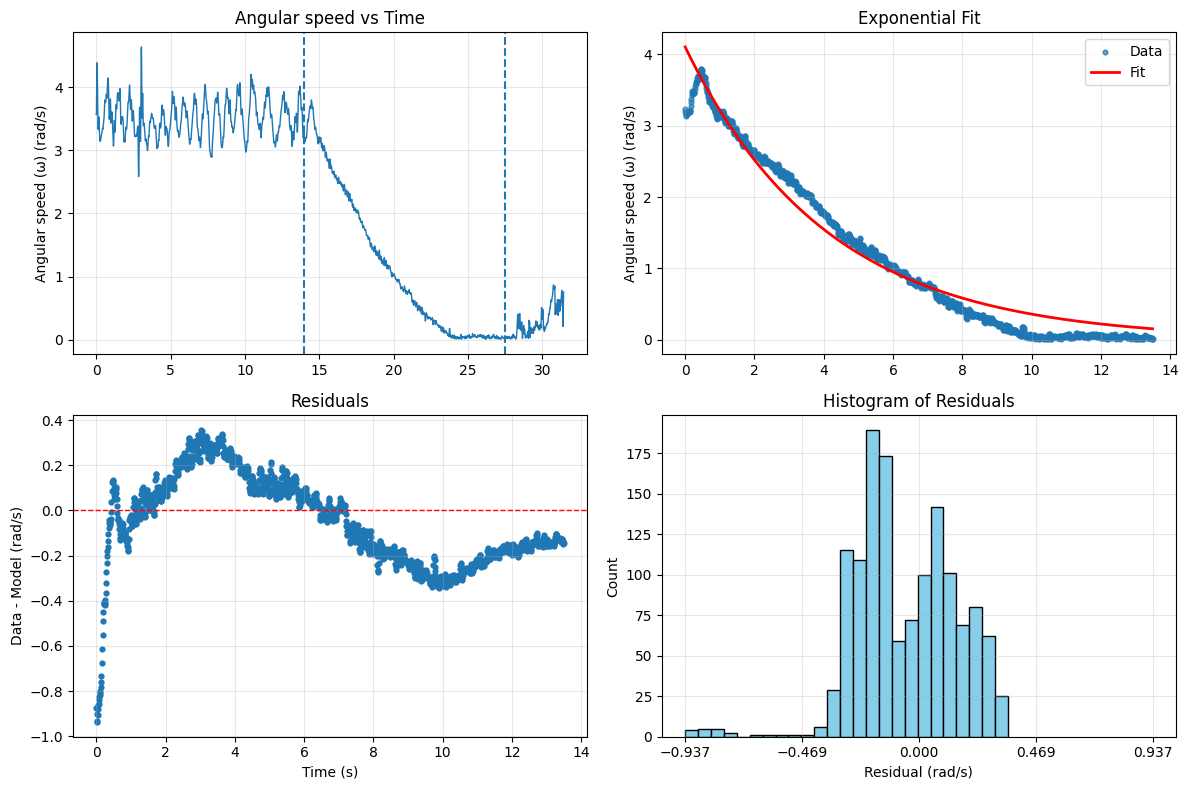

R^2 = 0.9656


In [45]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Top-left: raw data
ax[0, 0].plot(time, omega, lw=1)
ax[0, 0].axvline(t_start, ls='--')
ax[0, 0].axvline(t_end, ls='--')
ax[0, 0].set_title('Angular speed vs Time')
ax[0, 0].set_ylabel('Angular speed (ω) (rad/s)')
ax[0, 0].grid(True, alpha=0.3)

# Top-right: trimmed data + fit
ax[0, 1].scatter(time_fit, omega_fit, s=12, alpha=0.7, label='Data')
ax[0, 1].plot(time_fit, omega_model, 'r-', lw=2, label='Fit')
ax[0, 1].set_title('Exponential Fit')
ax[0, 1].set_ylabel('Angular speed (ω) (rad/s)')
ax[0, 1].legend()
ax[0, 1].grid(True, alpha=0.3)

# Bottom-left: residuals
ax[1, 0].scatter(time_fit, residuals, s=12)
ax[1, 0].axhline(0, color='r', ls='--', lw=1)
ax[1, 0].set_title('Residuals')
ax[1, 0].set_xlabel('Time (s)')
ax[1, 0].set_ylabel('Data - Model (rad/s)')
ax[1, 0].grid(True, alpha=0.3)

# Bottom-right: histogram of residuals
ax[1, 1].hist(residuals, bins='auto', edgecolor='black', color='skyblue')
ax[1, 1].set_title('Histogram of Residuals')
ax[1, 1].set_xlabel('Residual (rad/s)')
ax[1, 1].set_ylabel('Count')
ax[1, 1].grid(True, alpha=0.3)

# Adjust x-axis for clarity
max_abs_residual = np.max(np.abs(residuals))
ax[1, 1].set_xlim(-max_abs_residual * 1.1, max_abs_residual * 1.1) # Symmetric limits
ax[1, 1].set_xticks(np.linspace(-max_abs_residual * 1.0, max_abs_residual * 1.0, 5)) # Fewer, evenly spaced ticks

plt.tight_layout()
plt.show()

# A simple goodness-of-fit number
ss_res = np.sum(residuals**2)
ss_tot = np.sum((omega_fit - np.mean(omega_fit))**2)
r_squared = 1 - ss_res/ss_tot
print(f'R^2 = {r_squared:.4f}')

In [47]:
sigma_omega0, sigma_beta = np.sqrt(np.diag(pcov))
print("Fitted parameters with uncertainty:")
print(f"omega_0 = {omega0_fit:.3f} ± {sigma_omega0:.3f} rad/s")
print(f"beta    = {beta_fit:.4f} ± {sigma_beta:.4f} s^-1")

Fitted parameters with uncertainty:
omega_0 = 4.105 ± 0.021 rad/s
beta    = 0.2438 ± 0.0018 s^-1


The sensor was $\pm$0.01 rad/s, which can cause problems for smaller readings.

Some error that can occur with my experiment is the chair slowing down faster than other, or the phone is not level the entire experiment.

I would say that my data was expected, it followed the damping equation and was a pretty good fit.